# 04 — Feature Engineering Olist (Phase 5)

Ce notebook execute le pipeline de feature engineering (`src/features/build_features.py`) sur `data/processed/olist_customers_clean.csv` (93 358 clients, produit par la Phase 3) et explore le resultat.

**Rappel RFM** : Recency (delai depuis la derniere commande), Frequency (nombre de commandes), Monetary (montant depense) sont les 3 dimensions classiques de segmentation client. Ce notebook calcule aussi le label `churn` (recency > 180 jours), encode les variables categorielles et normalise les features numeriques en vue du clustering (Phase 6) et du modele de prediction de churn (Phase 7).

## 1. Chargement des donnees

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Le notebook est exécuté depuis notebooks/, donc la racine du projet est le
# dossier parent. On l'ajoute à sys.path pour pouvoir importer src.features
# comme un package, exactement comme le font build_features.py et feature_report.py.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.eda.analysis import load_customers_clean
from src.features import build_features

raw_df = load_customers_clean()
print("Shape :", raw_df.shape)
raw_df.head()

Shape : (93358, 8)


,customer_unique_id,total_orders,total_spent,avg_review_score,first_order_date,last_order_date,most_frequent_category,customer_state
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,5.0,2018-05-10 10:56:27,2018-05-10 10:56:27,bed_bath_table,SP
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,4.0,2018-05-07 11:11:27,2018-05-07 11:11:27,health_beauty,SP
2,0000f46a3911fa3c0805444483337064,1,86.22,3.0,2017-03-10 21:05:03,2017-03-10 21:05:03,stationery,SC
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,4.0,2017-10-12 20:29:41,2017-10-12 20:29:41,telephony,PA
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,5.0,2017-11-14 19:45:42,2017-11-14 19:45:42,telephony,SP


## 2. Execution du pipeline de feature engineering

In [2]:
features_df = build_features.run_feature_engineering()
features_df.shape

=== Feature engineering Olist - 2026-07-25T14:16:35 ===



Chargement : 93358 lignes x 8 colonnes
[ETAPE 1] date_reference = 2018-08-29 (seuil churn = 180 jours)
[ETAPE 1] churn=0 : 41.08% | churn=1 : 58.92%
[ETAPE 2] RFM : frequency/monetary_log/customer_tenure_days/avg_days_between_orders calcules ; R_score, F_score (base sur le rang, cf. docstring), M_score, rfm_score (moyenne=2.50)
[ETAPE 3] state_encoded : 27 etats distincts | category_encoded : 72 categories distinctes (NaN -> 'unknown')
[ETAPE 3] Encodeurs sauvegardes dans C:\Users\amenm\Desktop\Customer Intelligence Platform\Customer-Intelligence-Platform-End-to-End-Data-AI-Engineering-Project\models\encoders
[ETAPE 4] StandardScaler applique sur ['recency_days', 'frequency', 'monetary_log', 'customer_tenure_days', 'avg_review_score'] -> ['recency_scaled', 'frequency_scaled', 'monetary_scaled', 'tenure_scaled', 'review_scaled']
[ETAPE 4] Scaler sauvegarde dans C:\Users\amenm\Desktop\Customer Intelligence Platform\Customer-Intelligence-Platform-End-to-End-Data-AI-Engineering-Project\mod

[ETAPE 5] C:\Users\amenm\Desktop\Customer Intelligence Platform\Customer-Intelligence-Platform-End-to-End-Data-AI-Engineering-Project\data\processed\olist_features.csv : 93358 lignes x 25 colonnes
[ETAPE 5] Colonnes : ['customer_unique_id', 'total_orders', 'total_spent', 'avg_review_score', 'first_order_date', 'last_order_date', 'most_frequent_category', 'customer_state', 'recency_days', 'churn', 'frequency', 'monetary_log', 'customer_tenure_days', 'avg_days_between_orders', 'R_score', 'F_score', 'M_score', 'rfm_score', 'state_encoded', 'category_encoded', 'recency_scaled', 'frequency_scaled', 'monetary_scaled', 'tenure_scaled', 'review_scaled']
[ETAPE 5] C:\Users\amenm\Desktop\Customer Intelligence Platform\Customer-Intelligence-Platform-End-to-End-Data-AI-Engineering-Project\data\processed\olist_features_scaled.csv : 93358 lignes x 7 colonnes
[ETAPE 5] Distribution churn : churn=0 41.08% | churn=1 58.92%


(93358, 25)

## 3. Distribution du label churn

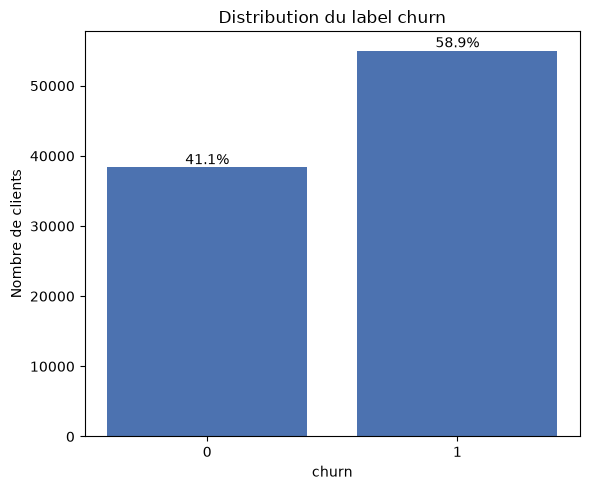

In [3]:
churn_counts = features_df["churn"].value_counts().sort_index()
churn_pct = features_df["churn"].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(churn_counts.index.astype(str), churn_counts.values, color="#4C72B0")
for bar, pct in zip(bars, churn_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{pct:.1f}%",
            ha="center", va="bottom")
ax.set_title("Distribution du label churn")
ax.set_xlabel("churn")
ax.set_ylabel("Nombre de clients")
plt.tight_layout()
plt.show()

## 4. Distribution de recency_days

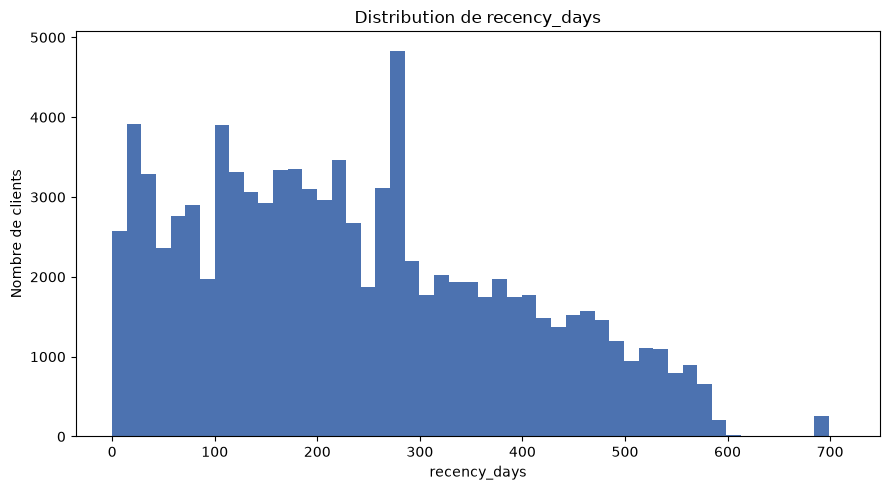

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(features_df["recency_days"], bins=50, color="#4C72B0")
ax.set_title("Distribution de recency_days")
ax.set_xlabel("recency_days")
ax.set_ylabel("Nombre de clients")
plt.tight_layout()
plt.show()

## 5. recency_days vs monetary_log, colore par churn

Couleur par identite (0=bleu, 1=rouge) plutot que par une teinte unique, pour voir si les deux populations churn/non-churn se separent visuellement sur ces deux axes.

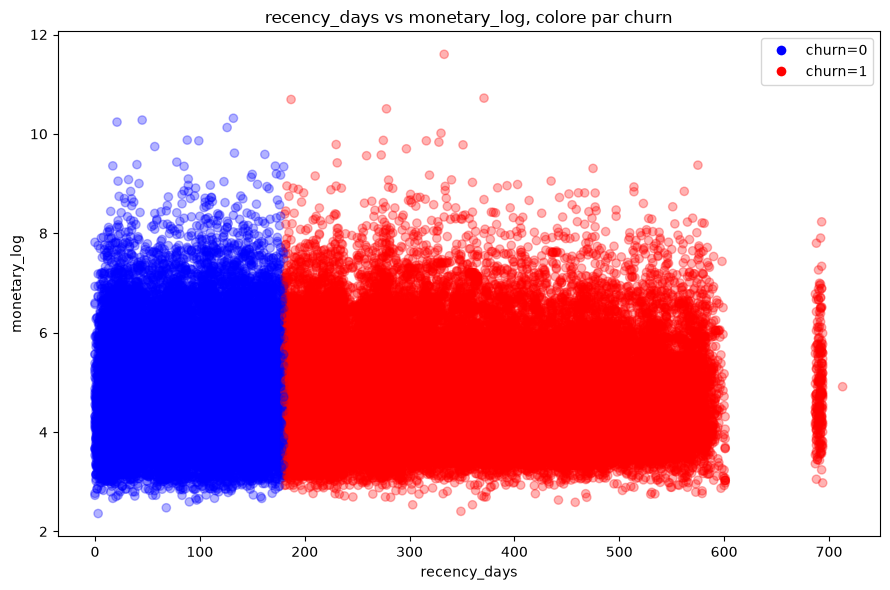

In [5]:
colors = features_df["churn"].map({0: "blue", 1: "red"})

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(features_df["recency_days"], features_df["monetary_log"],
           c=colors, alpha=0.3)
ax.set_title("recency_days vs monetary_log, colore par churn")
ax.set_xlabel("recency_days")
ax.set_ylabel("monetary_log")
handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="blue", markersize=8, label="churn=0"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="red", markersize=8, label="churn=1"),
]
ax.legend(handles=handles)
plt.tight_layout()
plt.show()

## 6. Correlation entre toutes les features numeriques et churn

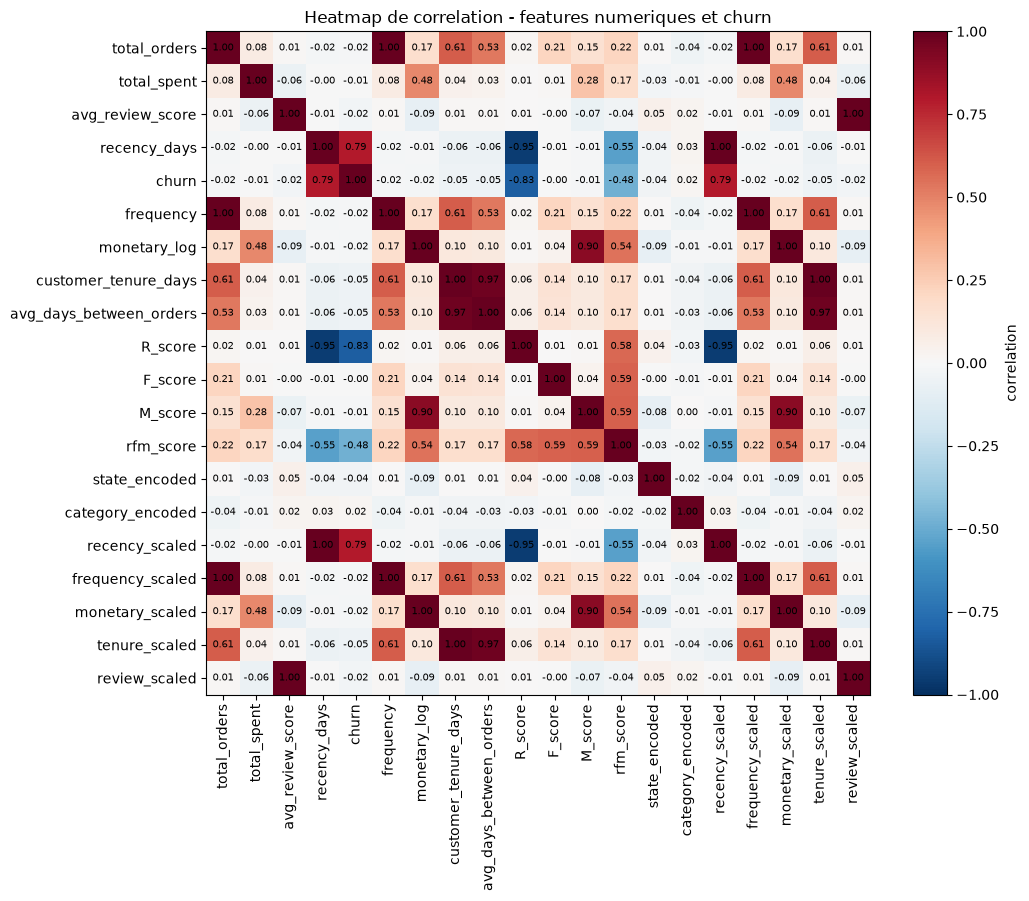

In [6]:
numeric_df = features_df.select_dtypes(include="number")
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, label="correlation")
ax.set_title("Heatmap de correlation - features numeriques et churn")
plt.tight_layout()
plt.show()

## 7. Apercu du dataset final (olist_features.csv)

In [7]:
pd.set_option("display.max_columns", None)
features_df.head(10)

,customer_unique_id,total_orders,total_spent,avg_review_score,first_order_date,last_order_date,most_frequent_category,customer_state,recency_days,churn,frequency,monetary_log,customer_tenure_days,avg_days_between_orders,R_score,F_score,M_score,rfm_score,state_encoded,category_encoded,recency_scaled,frequency_scaled,monetary_scaled,tenure_scaled,review_scaled
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,5.0,2018-05-10 10:56:27,2018-05-10 10:56:27,bed_bath_table,SP,111,0,1,4.962145,0,0.0,4,1,3,2.666667,25,7,-0.825357,-0.159829,0.162904,-0.105548,0.658041
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,4.0,2018-05-07 11:11:27,2018-05-07 11:11:27,health_beauty,SP,114,0,1,3.338967,0,0.0,3,1,1,1.666667,25,43,-0.805697,-0.159829,-1.623560,-0.105548,-0.124462
2,0000f46a3911fa3c0805444483337064,1,86.22,3.0,2017-03-10 21:05:03,2017-03-10 21:05:03,stationery,SC,536,1,1,4.468434,0,0.0,1,1,2,1.333333,23,66,1.959873,-0.159829,-0.380473,-0.105548,-0.906964
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,4.0,2017-10-12 20:29:41,2017-10-12 20:29:41,telephony,PA,320,1,1,3.798182,0,0.0,2,1,1,1.333333,13,68,0.544321,-0.159829,-1.118150,-0.105548,-0.124462
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,5.0,2017-11-14 19:45:42,2017-11-14 19:45:42,telephony,SP,287,1,1,5.287711,0,0.0,2,1,3,2.000000,25,68,0.328056,-0.159829,0.521221,-0.105548,0.658041
5,0004bd2a26a76fe21f786e4fbd80607f,1,166.98,4.0,2018-04-05 19:33:16,2018-04-05 19:33:16,garden_tools,SP,145,0,1,5.123845,0,0.0,3,1,3,2.333333,25,42,-0.602539,-0.159829,0.340870,-0.105548,-0.124462
6,00050ab1314c0e55a6ca13cf7181fecf,1,35.38,4.0,2018-04-20 12:57:23,2018-04-20 12:57:23,telephony,SP,131,0,1,3.594019,0,0.0,3,1,1,1.666667,25,68,-0.694288,-0.159829,-1.342851,-0.105548,-0.124462
7,00053a61a98854899e70ed204dd4bafe,1,838.36,1.0,2018-02-28 11:15:41,2018-02-28 11:15:41,sports_leisure,PR,182,1,1,6.732640,0,0.0,3,1,4,2.666667,17,65,-0.360060,-0.159829,2.111504,-0.105548,-2.471968
8,0005e1862207bf6ccc02e4228effd9a0,1,150.12,4.0,2017-03-04 23:32:12,2017-03-04 23:32:12,fashion_bags_accessories,RJ,542,1,1,5.018074,0,0.0,1,1,3,1.666667,18,28,1.999194,-0.159829,0.224459,-0.105548,-0.124462
9,0005ef4cd20d2893f0d9fbd94d3c0d97,1,129.76,1.0,2018-03-12 15:22:12,2018-03-12 15:22:12,sports_leisure,MA,169,0,1,4.873364,0,0.0,3,1,3,2.333333,9,65,-0.445255,-0.159829,0.065191,-0.105548,-2.471968


## 8. Conclusions et decisions pour la suite

1. **`R_score`/`recency_days` sont quasi-mecaniquement correles a `churn` (corr ~0.80-0.83) car `churn` est directement derive d'un seuil sur `recency_days`.** C'est une fuite de donnees (data leakage) attendue, pas un signal predictif : le modele de churn du **Prompt 7 doit exclure `recency_days`, `recency_scaled` et `R_score`** de ses features d'entree, sous peine d'apprendre une tautologie plutot qu'un vrai pattern de comportement.
2. **`frequency`/`monetary_log`/`avg_review_score` sont quasi decorreles de `churn`** (|corr| < 0.02). Le churn ne semble pas explique par ces variables seules : le **Prompt 7** devra probablement chercher du signal ailleurs (delai de livraison, categorie, saisonnalite d'achat) ou accepter un modele a performance modeste sur ces seules features RFM.
3. **La distribution de `recency_days` est etalee sur toute la plage observable (0-713 jours), sans rupture nette autour du seuil de 180 jours.** Le seuil de churn reste une convention business, pas une frontiere naturelle des donnees — a garder en tete si le seuil est revu en Phase 7.
4. **`total_orders`/`frequency` est extremement asymetrique (97% des clients a 1 commande), ce qui a force un F_score base sur le rang plutot que sur les valeurs brutes.** Le **Prompt 6 (segmentation)** doit s'attendre a ce que 'frequency' distingue mal les clients entre eux : les features de recency et de monetary porteront probablement plus de variance utile au clustering.
5. **Les features `_scaled` (recency_scaled, frequency_scaled, monetary_scaled, tenure_scaled, review_scaled) sont pretes dans `olist_features_scaled.csv`** specifiquement pour un algorithme base sur la distance : le **Prompt 6** peut les utiliser directement sans re-scaler.
6. **Le desequilibre de classes (58.9% churn=1 / 41.1% churn=0) est modere, pas extreme.** Le **Prompt 7** n'a probablement pas besoin de SMOTE, mais devra evaluer le modele avec F1/precision/recall/ROC-AUC plutot que l'accuracy seule (un modele naif "toujours churn=1" atteindrait deja ~59%).